<a href="https://colab.research.google.com/github/AndreaBravo-DA/Proyecto_Movilidad-urbana-y-productividad-economica-en-ciudades-de-LATAM/blob/main/Movilidad_Urbana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Limpieza de datos

#### 1. Carga de datos y vista rápida

In [ ]:
# importar librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re

In [ ]:
# cargar archivos

traffic = pd.read_csv('/content/sample_data/tomtom_traffic.csv')

traffic = pd.read_csv('/content/sample_data/tomtom_traffic.csv')


In [ ]:
# mostrar las primeras 5 filas de traffic

traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
# mostrar las primeras 5 filas de eco

eco.head(5)

,year,city,country,gdp_per_capita,unemployment_pct,pm25,population_millions,population
0,2023,buenos-aires,ARG,1578200.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,BRA,1447500.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,BRA,1314200.0,9.8,"19,10",13.6,13600000.0
3,2023,brasilia,BRA,1599900.0,8.3,"13,50",4.7,4700000.0
4,2023,salvador,BRA,876100.0,13.1,"16,00",3.9,3900000.0



---
#### 2. Explorar, limpiar y preparar los datos

In [ ]:
# Examinar la estructura de traffic

traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

**Notas:**

Las columnas UpdateTimeUTC y UpdateTimeUTCWeekAgo es del tipo texto, cuando estas deberan ser del tipo DATETIME'.
En todas las columnas se tiene el mismo número de datos, por lo que no existen valores nulos.
JamsCount tiene inconsistencia en el tipo de datos, este deberia ser del tipo Integer, puesto que es un conteo de embotellamientos.
Estandarizar el formato decimal, si sera utilizado con (,) o con (.)
Estandarizar el nombre de país.

In [ ]:
# Examinar la estructura de eco

eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 30 non-null     int64  
 1   city                 30 non-null     object 
 2   country              30 non-null     object 
 3   gdp_per_capita       30 non-null     float64
 4   unemployment_pct     30 non-null     float64
 5   pm25                 30 non-null     object 
 6   population_millions  30 non-null     float64
 7   population           30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


**Notas.**

Las columnas City GDP/capita, Unemployment %, PM2.5 (μg/m³)  y Population (M)  estan en formato object, cuando corresponden al tipo Float (númerico).
Se tiene el mismo número de datos en todas las columnas por lo que no existen valores nulos.
Estandarizar el formato decimal, si sera utilizado con (,) o con (.).
Estandarizar el nombre del país.
Quitar el signo de (%) y otro tipo de caracteres en los datos que contiene la columna Unemployment y `PM2.5 (μg/m³).

----

#### 3. Renombrar columnas

In [ ]:
# Mostrar las columnas del dataset

traffic.columns

Index(['Country', 'City', 'UpdateTimeUTC', 'JamsDelay', 'TrafficIndexLive',
       'JamsLengthInKms', 'JamsCount', 'TrafficIndexWeekAgo',
       'UpdateTimeUTCWeekAgo', 'TravelTimeLivePer10KmsMins',
       'TravelTimeHistoricPer10KmsMins', 'MinsDelay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de traffic

traffic_new_columns ={
    'Country': 'country',
    'City': 'city',
    'UpdateTimeUTC': 'update_time_utc',
    'JamsDelay': 'jams_delay',
    'TrafficIndexLive': 'traffic_index_live',
    'JamsLengthInKms': 'jams_length_in_kms',
    'JamsCount': 'jams_count',
    'TrafficIndexWeekAgo': 'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins': 'travel_time_live_per10_kms_mins',
    'TravelTimeHistoricPer10KmsMins': 'travel_time_historic_per10_kms_mins',
    'MinsDelay': 'mins_delay'
}

traffic = traffic.rename (columns = traffic_new_columns)



# verificar cambios

traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per10_kms_mins',
       'travel_time_historic_per10_kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco

eco_new_columns = {
    'Year': 'year',
    'city': 'city',
    'country': 'country',
    'city_gdp_capita': 'gdp_per_capita',
    'Unemployment % ': 'unemployment_pct',  # Corregir doble guión
    'pm2.5_μg_m³': 'pm25',  # Simplificar caracteres especiales
    'population_m': 'population_millions'
}

eco.columns

eco.columns = (eco.columns.str.lower()\
    .str.replace(' ','_')\
    .str.replace('%','pct')\
    .str.replace('(','')\
    .str.replace(')','')\
    .str.replace('/','_'))

eco = eco.rename (columns = eco_new_columns)

# verificar cambios

eco.columns

Index(['year', 'city', 'country', 'gdp_per_capita', 'unemployment_pct', 'pm25',
       'population_millions', 'population'],
      dtype='object')

----

#### 4. Corrección de formatos

In [ ]:
# Convertir las columnas de traffic a tipo fecha

traffic['update_time_utc'] =  pd.to_datetime(traffic['update_time_utc'])

traffic['update_time_utc_week_ago'] =  pd.to_datetime(traffic['update_time_utc_week_ago'])

# verificar el cambio

traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per10_kms_mins      1004464 non-null  fl

In [ ]:
# Limpia separadores y convierte columnas numéricas en eco

eco['gdp_per_capita'] = eco['gdp_per_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype('float')


eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%','').str.replace(',','.').astype('float')



eco['population_millions'] = eco['population_millions'].astype(str).str.replace(',','.').astype('float')



# Calcula la población total en unidades absolutas (Multiplica * 1000000)

eco['population'] = eco['population_millions'] * 1000000

# verificar el cambio

eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 30 non-null     int64  
 1   city                 30 non-null     object 
 2   country              30 non-null     object 
 3   gdp_per_capita       30 non-null     float64
 4   unemployment_pct     30 non-null     float64
 5   pm25                 30 non-null     object 
 6   population_millions  30 non-null     float64
 7   population           30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,gdp_per_capita,unemployment_pct,pm25,population_millions,population
0,2023,buenos-aires,ARG,15782000.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,BRA,14475000.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,BRA,13142000.0,9.8,"19,10",13.6,13600000.0


In [ ]:
# Diccionario para mapear nombres de países

country_mapping = {
    'Argentina': 'ARG',
    'Brazil': 'BRA',
    'Chile': 'CHL',
    'Colombia': 'COL',
    'Mexico': 'MEX',
    'Peru': 'PER',
    'Uruguay': 'URY'
}

# Aplicar el mapeo al dataset económico

eco['country'] = eco['country'].replace(country_mapping)

# Verificar el cambio

print("Países después del mapeo en eco:")
print(sorted(eco ['country'].unique()))

Países después del mapeo en eco:
['ARG', 'BRA', 'CHL', 'COL', 'MEX', 'PER', 'URY']



---


## Procesamiento de datos



#### 5. Extraer año y filtrar

In [ ]:
# Extraer el año de las fechas en update_time_utc

traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio

traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024

traffic_2024 = traffic [traffic ['year'] == 2024].copy()

# Revisar dataframes nuevos

display(traffic_2024.head())

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


In [ ]:
# Filtra los registros del año 2024

eco_2024 = eco [eco ['year'] == 2024].copy()


# Revisar dataframes nuevos

display(eco_2024.head())

,year,city,country,gdp_per_capita,unemployment_pct,pm25,population_millions,population
15,2024,buenos-aires,ARG,18117000.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,BRA,14703000.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,BRA,13349000.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,BRA,16251000.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,BRA,8899000.0,12.4,"15,20",3.9,3900000.0



---

#### 6. Analizar y resumir datos de movilidad

In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año

traffic_city_year_2024 = traffic_2024.groupby (['city','country','year']).agg ({
    'jams_delay': 'mean',
    'traffic_index_live':'mean',
    'jams_length_in_kms':'mean',
    'jams_count':'mean',
    'mins_delay':'mean',
    'travel_time_live_per10_kms_mins':'mean',
    'travel_time_historic_per10_kms_mins':'mean'
    }).reset_index()


# Mostrar resultado

traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [ ]:
#Ordenar los datos de forma ascendente

traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


**Notas:**

La ciudad con el mayor tiempo promedio de tráfico es la Ciudad de Mexico, la cual se encuentra en México (Latinoamérica).


---

#### 7. Unir movilidad y economía

Combinar los datasets para analizar cómo se relacionan los indicadores económicos con los de movilidad.

In [ ]:
# Verificar años únicos en traffic

print("Años en traffic:", traffic_city_year_2024['year'].unique())

# Verificar años únicos en eco

print("Años en eco:", eco_2024 ['year'].unique())

Años en traffic: [2024]
Años en eco: [2024]


In [ ]:
# Seleccionar columnas clave de tráfico y economía

left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count',
             'mins_delay','travel_time_live_per10_kms_mins',
             'travel_time_historic_per10_kms_mins']

right_cols = ['city','year','country','gdp_per_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos

traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

In [ ]:
# Unir datasets

merged = traffic_2024_small.merge(
    eco_2024_small,
    on=['city','country'],
    how='inner'
)

#Mostrar las primeras 5 filas

merged.head(5)

,city,country,year_x,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins,year_y,gdp_per_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,2024,11124000.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,2024,11442000.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,2024,16251000.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,2024,18117000.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,2024,12381000.0,8.2,"13,50",3700000.0


In [ ]:
# Contar cuántas ciudades hay por país

merged['country'].value_counts()

,count
country,
BRA,9
COL,1
ARG,1
PER,1
MEX,1
URY,1
CHL,1


In [ ]:
# Contar total de ciudades

total_ciudades = len(merged)
print(f"Total de ciudades: {total_ciudades}")

# Contar total de países únicos

total_paises = merged['country'].nunique()
print(f"Total de países: {total_paises}")



# Ciudades específicas en el DataFrame

print("\nCiudades en el dataset:")
print(merged['city'].tolist())

Total de ciudades: 15
Total de países: 7

Ciudades en el dataset:
['belo-horizonte', 'bogota', 'brasilia', 'buenos-aires', 'curitiba', 'fortaleza', 'lima', 'mexico-city', 'montevideo', 'porto-alegre', 'recife', 'rio-de-janeiro', 'salvador', 'santiago', 'sao-paulo']


##Analisis de datos

#### 8. Visualizar relaciones entre economía y tráfico

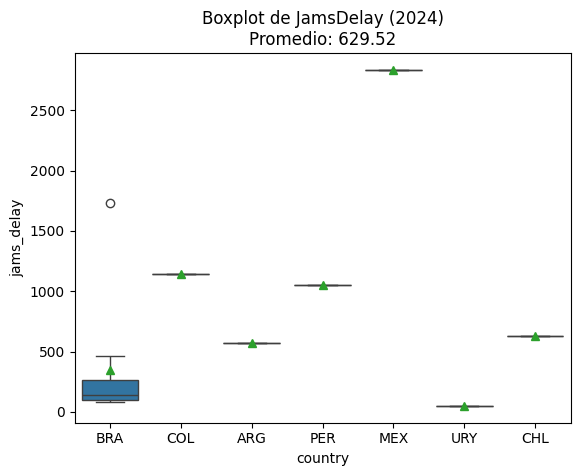

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay

sns.boxplot(data=merged, x='country', y='jams_delay',showmeans=True)

# obtener promedio para mostrarlo en título

mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()

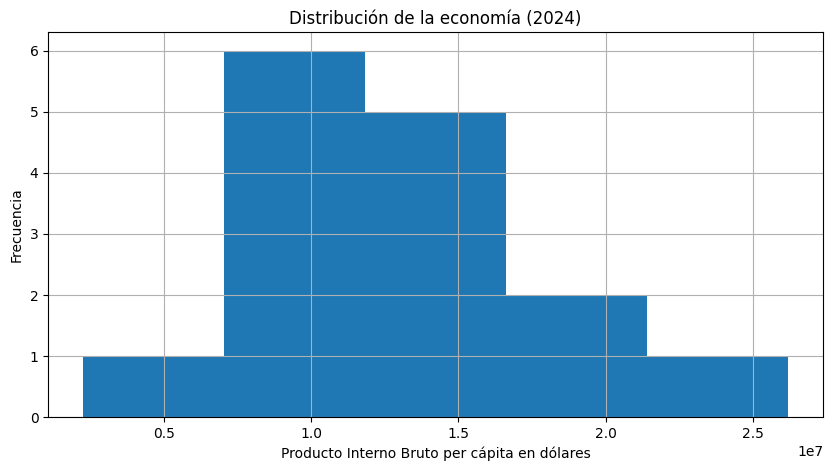

In [ ]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)

merged['gdp_per_capita'].hist(bins= 5,figsize=(10,5))

plt.title('Distribución de la economía (2024)')
plt.ylabel('Frecuencia')
plt.xlabel('Producto Interno Bruto per cápita en dólares')

plt.show()

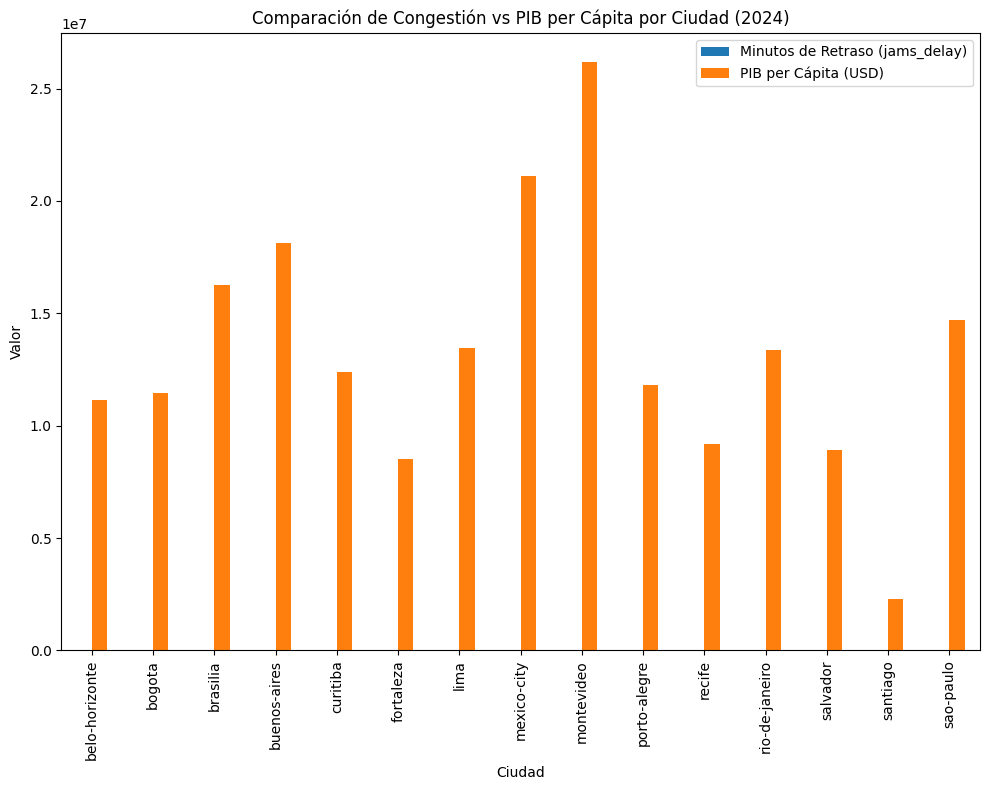

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad

merged.plot(x= 'city', y=['jams_delay', 'gdp_per_capita'],kind= 'bar',figsize=(10,8))
plt.title('Comparación de Congestión vs PIB per Cápita por Ciudad (2024)')
plt.ylabel('Valor')
plt.xlabel('Ciudad')
plt.xticks(rotation=90)
plt.legend(['Minutos de Retraso (jams_delay)', 'PIB per Cápita (USD)'])
plt.tight_layout()

plt.show()

In [ ]:
# Exporta el dataset final como CSV

merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

**Resumen Ejecutivo**

**Contexto & objetivo:**

Identificar las cuidades prospecto para poder invertir en infraestructura de transporte para aumentar la productividad y bienestar de la población. Dicho analisis se realizara en el periodo del año 2024, buscanco la relación entre la movilidad urbana (congestión y tiempos de viaje) con el PIB per cápita.

Se entiende como "PIB per cápita" al indicador económico que mide la riqueza promedio producida por habitante en un país durante un año, dividiendo el Producto Interno Bruto (PIB) total entre su población. Mientras que, el tiempo de traslado es el retraso total en minutos provocado por la congestión en las vías monitoreadas. Dicho tiempo, es para recorrer 10 km en condiciones normales (sin congestión) y el necesario para recorrer 10 km bajo condiciones reales de tráfico.

**Cobertura de datos:**

El analisis correspondiente se ejecuto para todas las cuidades con registros del año 2024, siendo un total de 15 ciudades, las cuales se albergan en 7 países. Teniendo la siguiente correlación:

· BRA 9 · PER 1 · URY 1 · COL 1 · MEX 1 · ARG 1 · CHL 1

**Metodología:**

Se renombraron las columnas para tener una visualización homogénea entre ambas tablas, es decir, sin mayúscula, sin elementos que pudieran entorpecer el llamado de las columnas al momento del análisis, y reemplazado los espacios con guiones. Se corrigieron los formatos de columnas para un adecuado análisis, por ejemplo, la columna de fecha para almacenar los datos como datetime. Se unifico el nombre de los países para que en ambas apareciera con abreviaturas.

Se realizo la extracción de los datos del año 2024 de los DataFrame. Se realizo la unión de ambas tablas. Posteriormente, se agruparon los datos por ciudades, país y año, calcularon los promedios de las variables. Para unir los datos del trafico y de la economía se realizaron por medio de la ciudad y del año. Se utiliza la unión por medio de INNER puesto que mantiene solo las filas que contienen coincidencias en ambos DataFrames.

**Hallazgos iniciales:**

* Montevideo, Uruguay es la cuidad con mayor PIB per cápita y menor congestión. Posicionándose como caso ideal. La infraestructura que posee ayuda al desarrollo de la productividad económica.

* La ciudad de México se presenta como un valor extremo, puesto que la congestión es muy alta, en comparación de otros países (~2,833 minutos). Esta ciudad requiere de atención prioritaria. Presenta un alto nivel de PIB pero también de tráfico. Es una oportunidad de inversión, el mejorar las vías podrían aumentar significativamente los ingresos del PIB.

* Las ciudades de Buenos Aires y Sao Paulo serían las ciudades con un PIB alto y una congestión vial moderada, por lo que serían las segundas en tener prioridad.

* Lima tienen un alto PIB, y una baja congestión por lo que se podría replicar casos de éxito de Montevideo, para bajar sus índices de tráfico.

* Otra ciudad para mejora es Bogota, puesto que tiene un PIB alto, pero su tráfico es considero como moderado, por lo que se podrían tener mejorar para bajar el índice de congestión, y aumentar su PIB.

* Para Salvador su tráfico es alto, en relativa al total de PIB que produce.

* Brasil tiene un Outlier en la gráfica de boxplot, por lo que es importante analizar los datos de las ciudades de este país. Muestra una gran variabilidad con valores extremos. Su rango es aproximado entre los 100 a los 1700 minutos. Teniendo que la mayoría de las ciudades tienen congestión moderada.

* Colombia, Argentina, Peru y Chile se establecen como datos están dentro de la media.

* Pocos de los países tienen un PIB per Cápita entre los 10,000 y los 12000 dólares.

* Algunas ciudades con PIB per cápita están entre los 15000 y los 18000 dólares.

* Se aprecia un sesgo hacia la derecha.


**Recomendaciones:**

* La infraestructura vial que tiene Montevideo es por medio de 4 carreteras centrales que conecta a sus diferentes ciudades externas al centro de la cuidad, la planeación territorial es estructurada y consistente para tener una movilidad exitosa, al igual que el tamaño de dicha cuidad no es grande, por lo que se puede tener un control territorial del crecimiento.

* Para México, Lima y Bogotá recomendaría hacer la construcción de vialidades centrales que conecten las ciudades de gran impacto en el PIB. Ciudades con una población grande para mejorar la conectividad y el derrame económico.

* Para Buenos Aires, Sao Paulo revisaría las políticas de transporte para adaptarlas en funcionalidad de la cuidad y del crecimiento de esta.

* El Salvador es grande territorialmente, por lo que buscaría el transporte y la distribución de carreteras que mejor abarque la extensión territorial, Al igual que las políticas de transporte.

* Brasil cuenta con patrones diferentes entre el PIB y la congestión, esto debido a los usos de suelo, infraestructura vial, condiciones territoriales como topografías, la especialización económica entre las ciudades.

* Para la medición ROI se calcularía el valor económico del tiempo por medio de los índices del tráfico en los 10 kms y el PIB per cápita. Se observaría la diferencia entre el valor de PIB antes de la mejora y después de la mejora, al igual que el tiempo de retraso de congestión bajarla con al menos un 10% del actual. Se podría calcular de la siguiente forma: ROI = (Beneficio Económico Anual - Costo de Inversión) / Costo de Inversión x 100. Se estimaría conforme al número de personas que beneficia directamente la nueva infraestructura.